In [21]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

np.random.seed(30)

In [22]:
seed = 30
rng = np.random.default_rng(seed=seed)

### Part 1

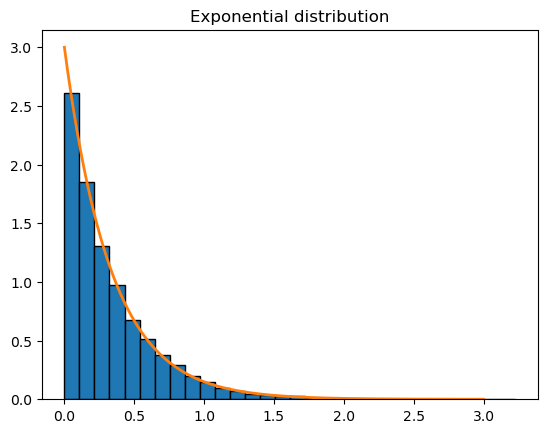

KS statistic D = 0.00798471012687968


In [23]:
def exponential(lbd):
    U = np.random.uniform(0,1)
    X = -np.log(U)/lbd
    return X

def exponential_analytical(x, lbd):
    return lbd * np.exp(-lbd * x)

lbd = 3
obs_exponential = [exponential(lbd) for _ in range(10000)]
t = np.linspace(0, 3, 10000)
plt.hist(obs_exponential, bins=30, density=True, edgecolor='black')
plt.plot(t, exponential_analytical(t, lbd), linewidth=2)
plt.title('Exponential distribution')
plt.show()


## Kolmogorov-Smirnov test

def smirnov(data, CDF):
    data_sorted = np.sort(data)
    p = np.arange(len(data_sorted)) / (len(data_sorted) - 1)   # empirical CDF
    p_cdf = CDF(data_sorted)                      # theoretical CDF
    D = np.max(np.abs(p - p_cdf))                 # sup
    return D

# Theoretical exponential CDF
def exp_cdf(x):
    return 1 - np.exp(-lbd * x)

D = smirnov(obs_exponential, exp_cdf)
print("KS statistic D =", D)

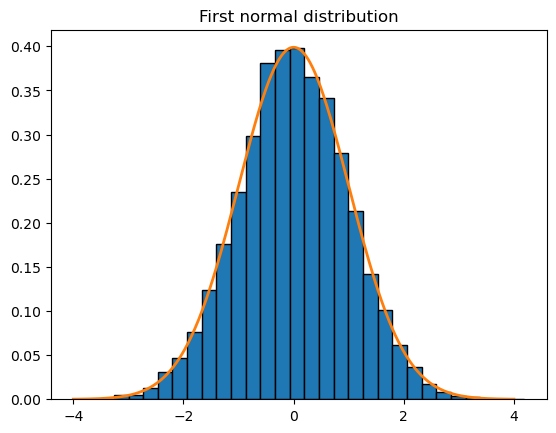

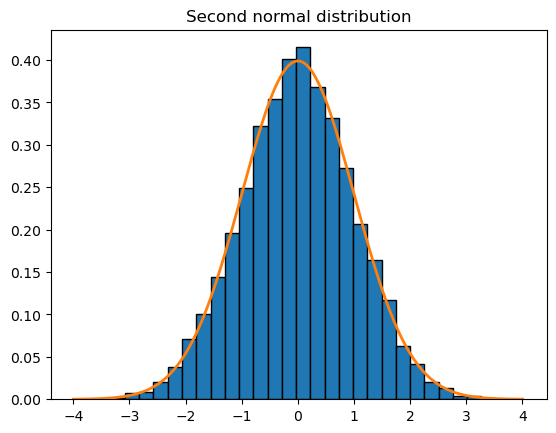

D1 = 0.006446085864173279
D2 = 0.0055461293117784055


In [24]:
def normal():
    U1 = np.random.uniform(0,1)
    U2 = np.random.uniform(0,1)
    Z1 = np.sqrt(-2*np.log(U1)) * np.cos(2*np.pi*U2)
    Z2 = np.sqrt(-2*np.log(U1)) * np.sin(2*np.pi*U2)
    return np.array([Z1, Z2])

def normal_analytical(x):
    return (1/np.sqrt(2*np.pi)) * np.exp(-0.5 * x**2)

obs_normal = np.array([normal() for _ in range(10000)])
t = np.linspace(-4, 4, 500)

plt.hist(obs_normal[:,0], bins=30, density=True, edgecolor='black')
plt.plot(t, normal_analytical(t), linewidth=2)
plt.title('First normal distribution')
plt.show()

plt.hist(obs_normal[:,1], bins=30, density=True, edgecolor='black')
plt.plot(t, normal_analytical(t), linewidth=2)
plt.title('Second normal distribution')
plt.show()

## Kolmogorov-Smirnov test

D1 = smirnov(obs_normal[:,0], ss.norm.cdf)
D2 = smirnov(obs_normal[:,1], ss.norm.cdf)

print("D1 =", D1)
print("D2 =", D2)

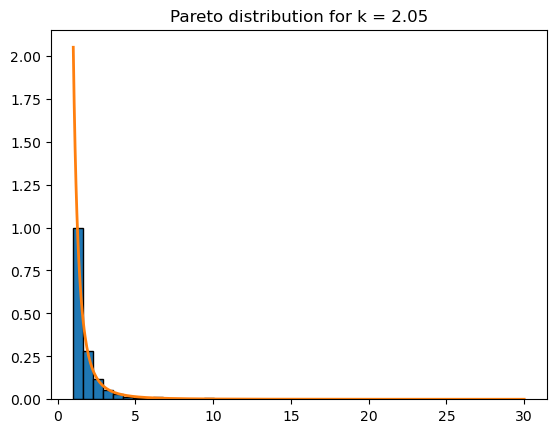

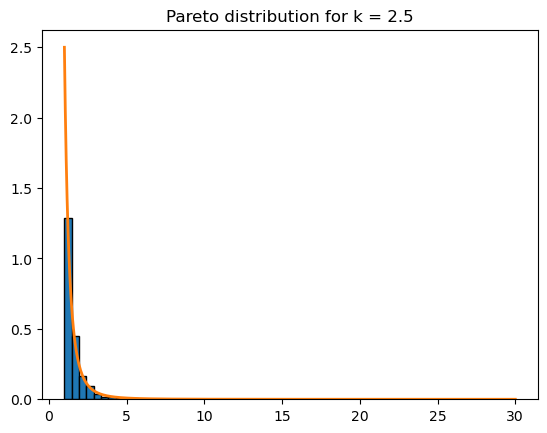

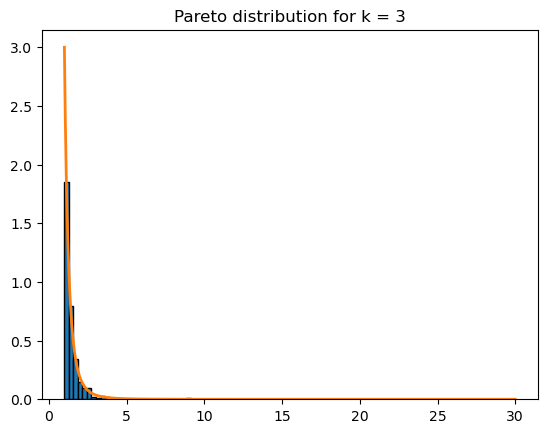

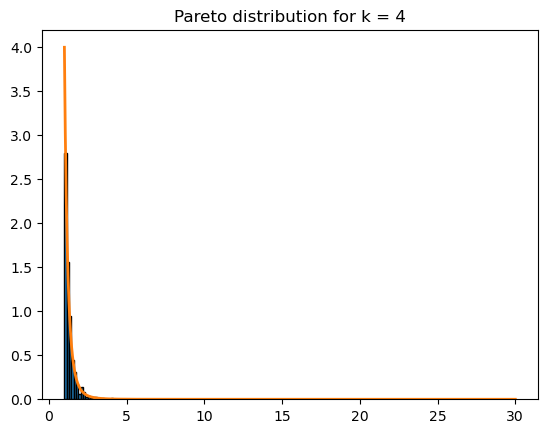

k = 2.05, KS statistic D = 0.01737
k = 2.5, KS statistic D = 0.02302
k = 3, KS statistic D = 0.02306
k = 4, KS statistic D = 0.01336


In [25]:
def pareto(k, beta):
    U = np.random.uniform(0,1)
    X = beta * U**(-1/k)
    return X

def pareto_analytical(t, k, beta):
    return (k * beta**k) / (t**(k+1))

beta = 1
k = [2.05, 2.5, 3, 4]
t = np.linspace(1, 30, 500)
for ki in k:
    obs_pareto = np.array([pareto(ki, beta) for _ in range(1000)])
    plt.hist(obs_pareto, density=True, bins=30, edgecolor='black')
    plt.plot(t, pareto_analytical(t, ki, beta), linewidth=2)
    plt.title(f"Pareto distribution for k = {ki}")
    plt.show()


## Kolmogorov-Smirnov test

def pareto_cdf(x, k, beta):
    x = np.asarray(x)
    return 1 - (beta / x)**k

for ki in k:
    obs_pareto = np.array([pareto(ki, beta) for _ in range(1000)])
    D = smirnov(obs_pareto, lambda x: pareto_cdf(x, ki, beta))
    print(f"k = {ki}, KS statistic D = {D:.5f}")

### Part 2

### Part 3

In [26]:
MEAN = []
VAR = []
np.random.seed(420)

# calc observed mean and var
for i in range(100):
    U = np.random.uniform(size=(2,5))
    Z_norm = (np.sqrt(-2*np.log(U[0])) * np.array([np.cos(2 * np.pi * U[1]), 
                                                np.sin(2 * np.pi * U[1])])).reshape(-1)
    
    MEAN.append(np.mean(Z_norm))
    VAR.append(np.var(Z_norm))

# Calc CI
MEAN_CI = []
VAR_CI = []
n_obs = 10
df = n_obs - 1
tcrit = ss.t.ppf(0.975,df=df)
chi2_lower = ss.chi2.ppf(0.05/2, df)
chi2_upper = ss.chi2.ppf(1 - 0.05/2, df)

for i in range(100):
    s = np.sqrt(VAR[i])
    margin = tcrit * s / np.sqrt(n_obs)

    ci = np.array([MEAN[i] - margin,
                   MEAN[i] + margin])

    MEAN_CI.append(ci)

    ci = np.array([df * s**2 / chi2_upper,
                   df * s**2 / chi2_lower])
    VAR_CI.append(ci)



MEAN_CI = np.array(MEAN_CI).reshape((100,2))
VAR_CI = np.array(VAR_CI).reshape((100,2))

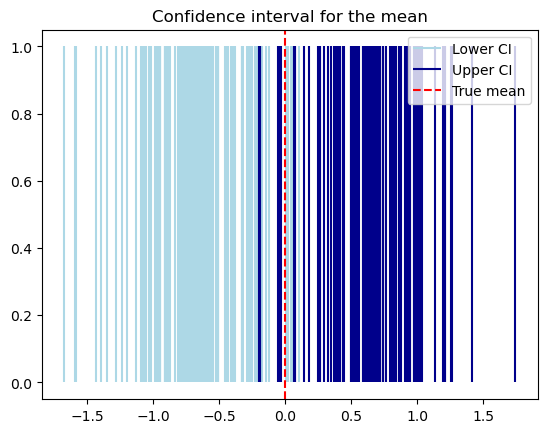

In [27]:
# MEAN CONFIDENCE INTERVAL
plt.vlines(MEAN_CI[:,0],0,1,color="lightblue", label="Lower CI")
plt.vlines(MEAN_CI[:,1],0,1,color="darkblue", label="Upper CI")

plt.axvline(0, color='red', linestyle='--', label="True mean")  # true mean
plt.title("Confidence interval for the mean")
plt.legend()
plt.show()

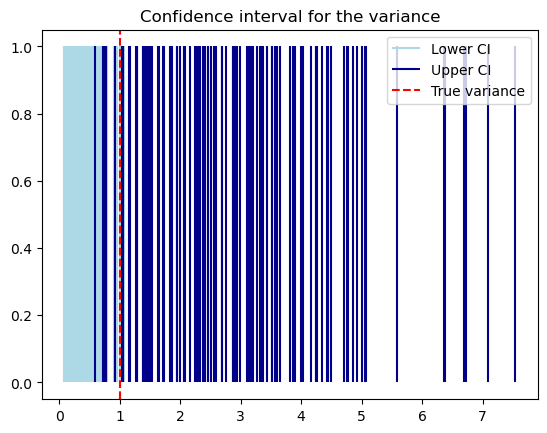

In [28]:
# VARIANCE CONFIDENCE INTERVAL
plt.vlines(VAR_CI[:,0],0,1,color="lightblue", label="Lower CI")
plt.vlines(VAR_CI[:,1],0,1,color="darkblue", label="Upper CI")

plt.axvline(1, color='red', linestyle='--', label="True variance")  # true mean
plt.title("Confidence interval for the variance")
plt.legend()
plt.show()

In [29]:
# Coverage MEAN
num = (MEAN_CI[:,0] <= 0) & (MEAN_CI[:,1] >= 0)
print(f"Coverage mean: {np.sum(num)/100}")

# Coverage variance
num = (VAR_CI[:,0] <= 1) & (VAR_CI[:,1] >= 1)
print(f"Coverage variance: {np.sum(num)/100}")

Coverage mean: 0.89
Coverage variance: 0.93


### Part 4

In [30]:
N = 10000
lam = 1
U1 = rng.uniform(low=0, high=1, size=N)
U2 = rng.uniform(low=0, high=1, size=N)
Y = - np.log(U1)/lam
X_pareto_comp = - np.log(U2)/Y

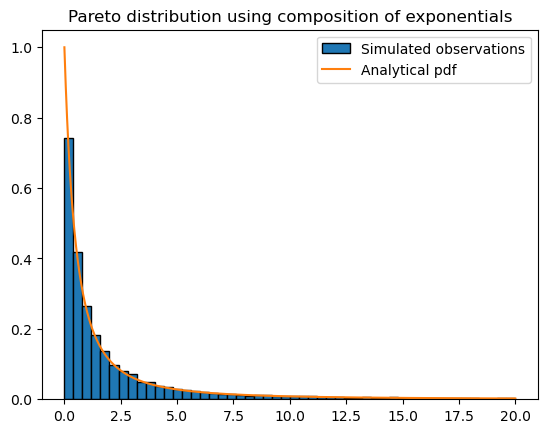

In [31]:
x = np.linspace(0,20,1000)
y = lam/((lam+x)**2)

plt.hist(X_pareto_comp, bins=50, range=(0,20), edgecolor='black', density=True, label='Simulated observations')
plt.plot(x, y, label='Analytical pdf')
plt.legend()
plt.title('Pareto distribution using composition of exponentials')
plt.show()

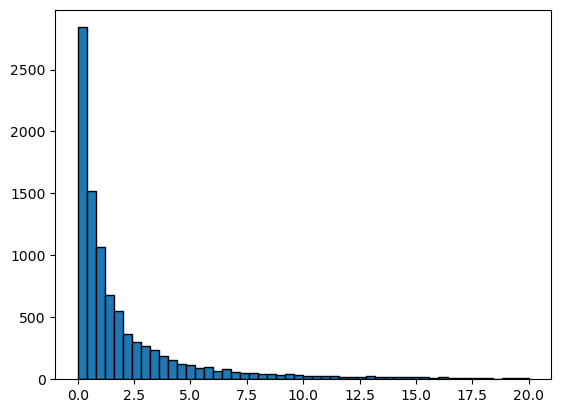

In [32]:
U = rng.uniform(low=0, high=1, size=N)
X_pareto_2 = beta*(1/U - 1)
plt.hist(X_pareto_2, bins=50, range=(0,20), edgecolor='black')
plt.show()

In [33]:
def est_cdf(x):
    Fx = np.zeros(len(x))
    for i in range(len(x)):
        Fx[i] = np.sum(X_pareto_comp <= x[i])/N
    return Fx

true_cdf = lambda x: 1-1/(1+x/lam)

xs = np.linspace(0,100,1000)
est = est_cdf(xs)
true = true_cdf(xs)              
Dn = np.max(np.abs(est-true))
Dstar = (np.sqrt(N) + 0.12 + 0.11/np.sqrt(N))*Dn
Dstar

0.6935395905109509